# Edge profiles from TIARA

In [1]:
import imas
import getpass
def get_ggd():
    backend = 12
    database = "ITER"
    shot = 122408
    run = 3
    username = getpass.getuser()
    dbentry = imas.DBEntry(backend, database, shot, run, username)
    status, idx = dbentry.open()
    status = dbentry.get("edge_profiles")
    return status
s = get_ggd()

In [2]:
nodes = s.grid_ggd[0].space[0].objects_per_dimension[0].object
number_of_nodes = len(nodes)
print(f"Number of nodes {number_of_nodes}")

Number of nodes 27203


In [3]:
for i in [165, 166, 167, 166,169,167]:
    print(nodes[i-1].geometry)

[4.1424799  0.78895688]
[4.14050913 0.78891569]
[4.14394712 0.72456038]
[4.14050913 0.78891569]
[4.14198637 0.72450835]
[4.14394712 0.72456038]


In [4]:
x = []
y = []

for i in range(number_of_nodes):
    x.append(nodes[i].geometry[0])
    y.append(nodes[i].geometry[1])

In [5]:
faces = s.grid_ggd[0].space[0].objects_per_dimension[2].object
number_of_faces = len(faces)
print(f"Number of faces: {number_of_faces}")

for i in range(10):
    face_nodes = len(faces[i].nodes)
    for j in range(face_nodes):
        index = faces[i].nodes[j]-1
        print(i+1, index, x[index], y[index])

Number of faces: 53385
1 164 4.14247989654541 0.788956880569458
1 165 4.140509128570557 0.7889156937599182
1 166 4.143947124481201 0.7245603799819946
2 164 4.14247989654541 0.788956880569458
2 167 4.139805316925049 0.9898421168327332
2 165 4.140509128570557 0.7889156937599182
3 165 4.140509128570557 0.7889156937599182
3 168 4.14198637008667 0.7245083451271057
3 166 4.143947124481201 0.7245603799819946
4 166 4.143947124481201 0.7245603799819946
4 143 4.149989128112793 0.6714320778846741
4 164 4.14247989654541 0.788956880569458
5 43 4.144432544708252 0.9898677468299866
5 167 4.139805316925049 0.9898421168327332
5 164 4.14247989654541 0.788956880569458
6 167 4.139805316925049 0.9898421168327332
6 169 4.137803077697754 0.9898310303688049
6 165 4.140509128570557 0.7889156937599182
7 165 4.140509128570557 0.7889156937599182
7 170 4.13125467300415 0.7887144088745117
7 168 4.14198637008667 0.7245083451271057
8 168 4.14198637008667 0.7245083451271057
8 171 4.145459175109863 0.671293318271637
8 

# Geometry

In [6]:
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline
%matplotlib notebook

<IPython.core.display.Javascript object>


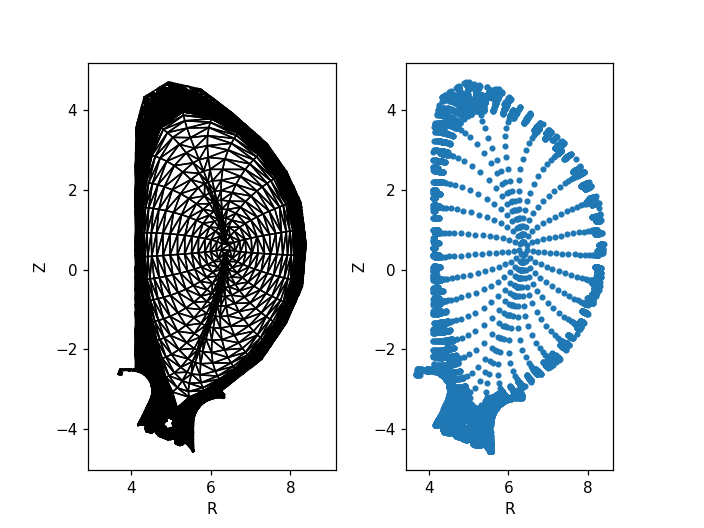

In [7]:
from matplotlib.patches import Polygon 

fig = plt.figure() 
ax = fig.add_subplot(121, aspect='equal')

for i in range(number_of_faces):
    face_nodes = len(faces[i].nodes)
    face_points = []
    for j in range(face_nodes):
        index = faces[i].nodes[j]-1
        face_points.append([x[index], y[index]])
        #print(i+1, index, x[index], y[index])
    ax.add_patch(Polygon(face_points, closed=True,fill=False)) 

ax.set_xlim((3.5,8.5)) 
ax.set_ylim((-7,7))
plt.xlabel('R')
plt.ylabel('Z')
plt.show()

In [8]:
plt.axis('equal')
ax = fig.add_subplot(122, aspect='equal')
plt.plot(x, y, '.')
plt.xlabel('R')
plt.ylabel('Z')
plt.show()